Импорт и настройка

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"Seed: {RANDOM_SEED}")

Seed: 42


## Поиск и источник данных

**Источник:** [Global Central Bank Rates 1945-2026](https://www.kaggle.com/datasets/fivethirtyeight/global-central-bank-rates-1945-2026) на Kaggle

**Почему выбрали:**
- Уникальный исторический охват (более 80 лет) — с 1945 по 2026 год
- Включает данные центральных банков разных стран (США, ЕС, Япония, Великобритания и др.)
- Содержит готовые признаки: скользящие средние, изменение ставок, периоды кризисов (GFC, COVID)
- Релевантная задача: прогнозирование решений центральных банков (повышение/снижение/удержание ставки)

In [30]:
df = pd.read_csv('../data/raw/global_central_bank_rates_1945_2026.csv')
print(f"Данные загружены. Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nПервые 3 строки:")
df.head(3)

Данные загружены. Размер: 24454 строк, 43 столбцов

Первые 3 строки:


,country_code,date,policy_rate_pct,rate_description,rate_notes,source_institution,year,month,time_period,country_name,...,rate_12m_min,is_all_time_high,is_all_time_low,era,gfc_period,covid_period,hike_cycle_2022_23,fed_rate,spread_vs_fed_bps,row_completeness_pct
0,AR,1993-04-01,0.63,Argentina,From 10 July 2025 onwards: no policy rate adop...,Central Bank of Argentina,1993,4,1993-04,Argentina,...,NaN,1,1,Great Moderation (1990s),0,0,0,3.0,-237.0,100.0
1,AR,1993-05-01,0.11,Argentina,From 10 July 2025 onwards: no policy rate adop...,Central Bank of Argentina,1993,5,1993-05,Argentina,...,NaN,0,1,Great Moderation (1990s),0,0,0,3.0,-289.0,100.0
2,AR,1993-06-01,0.53,Argentina,From 10 July 2025 onwards: no policy rate adop...,Central Bank of Argentina,1993,6,1993-06,Argentina,...,0.11,0,0,Great Moderation (1990s),0,0,0,3.0,-247.0,100.0


## Описание датасета

In [31]:
print(f"Строк: {df.shape[0]}")
print(f"Столбцов: {df.shape[1]}")
print(f"Стран: {df['country_name'].nunique()}")
print(f"Период: {df['date'].min()} - {df['date'].max()}")

print("\nТипы данных:")
print(df.dtypes.value_counts())

print("\n=== Список всех колонок ===")
for col in df.columns:
    print(f"  - {col}")

print("\n=== Проверка на выбросы (policy_rate_pct) ===")
q1 = df['policy_rate_pct'].quantile(0.25)
q3 = df['policy_rate_pct'].quantile(0.75)
iqr = q3 - q1
outliers = df[(df['policy_rate_pct'] < q1 - 1.5*iqr) | (df['policy_rate_pct'] > q3 + 1.5*iqr)]
print(f"Выбросов по IQR: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")

Строк: 24454
Столбцов: 43
Стран: 49
Период: 1945-01-01 - 2026-02-01

Типы данных:
object     23
float64    13
int64       7
Name: count, dtype: int64

=== Список всех колонок ===
  - country_code
  - date
  - policy_rate_pct
  - rate_description
  - rate_notes
  - source_institution
  - year
  - month
  - time_period
  - country_name
  - central_bank
  - region
  - continent
  - subregion
  - population
  - currency
  - capital
  - data_source
  - dataset_version
  - retrieved_date
  - build_timestamp
  - month_name
  - quarter
  - decade
  - rate_change_bps
  - rate_change_direction
  - rate_jan2022_base
  - cumulative_change_since_2022_bps
  - rate_cycle
  - rate_regime
  - rate_3m_avg
  - rate_12m_avg
  - rate_12m_max
  - rate_12m_min
  - is_all_time_high
  - is_all_time_low
  - era
  - gfc_period
  - covid_period
  - hike_cycle_2022_23
  - fed_rate
  - spread_vs_fed_bps
  - row_completeness_pct

=== Проверка на выбросы (policy_rate_pct) ===
Выбросов по IQR: 1668 (6.82%)
Q1: 3.00, Q

## Очистка данных: пропуски, дубли, выбросы, типы

In [ ]:
print("=== ДО ОЧИСТКИ ===")
print(f"Пропуски: {df.isnull().sum().sum()}")
print(f"Дубликаты: {df.duplicated().sum()}")

df = df.drop_duplicates()
print(f"\nПосле удаления дубликатов: {len(df)} строк")

threshold = 0.5
before = df.shape[1]
df = df.dropna(thresh=int(threshold * len(df)), axis=1)
print(f"Удалено колонок с >50% пропусков: {before - df.shape[1]}")

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"\n=== ПОСЛЕ ОЧИСТКИ ===")
print(f"Пропусков: {df.isnull().sum().sum()}")
print(f"Размер: {df.shape}")
print(f"Оставшиеся колонки: {list(df.columns)}")

=== ДО ОЧИСТКИ ===
Пропуски: 20531
Дубликаты: 0

После удаления дубликатов: 24454 строк
Удалено колонок с >50% пропусков: 0

=== ПОСЛЕ ОЧИСТКИ ===
Пропусков: 0
Размер: (24454, 43)
Оставшиеся колонки: ['country_code', 'date', 'policy_rate_pct', 'rate_description', 'rate_notes', 'source_institution', 'year', 'month', 'time_period', 'country_name', 'central_bank', 'region', 'continent', 'subregion', 'population', 'currency', 'capital', 'data_source', 'dataset_version', 'retrieved_date', 'build_timestamp', 'month_name', 'quarter', 'decade', 'rate_change_bps', 'rate_change_direction', 'rate_jan2022_base', 'cumulative_change_since_2022_bps', 'rate_cycle', 'rate_regime', 'rate_3m_avg', 'rate_12m_avg', 'rate_12m_max', 'rate_12m_min', 'is_all_time_high', 'is_all_time_low', 'era', 'gfc_period', 'covid_period', 'hike_cycle_2022_23', 'fed_rate', 'spread_vs_fed_bps', 'row_completeness_pct']


Таргет

In [ ]:
print(df['rate_change_direction'].value_counts())

target_map = {'Hike': 0, 'Hold': 1, 'Cut': 2}

df['target'] = df['rate_change_direction'].map(target_map)

before = len(df)
df = df.dropna(subset=['target'])
after = len(df)

print(f"\nУдалено строк с 'First Record': {before - after}")
print(f"Новое распределение target:")
print(df['target'].value_counts().sort_index())
print("0=Hike, 1=Hold, 2=Cut")

rate_change_direction
Hold            17698
Cut              3751
Hike             2956
First Record       49
Name: count, dtype: int64

Удалено строк с 'First Record': 49
Новое распределение target:
target
0.0     2956
1.0    17698
2.0     3751
Name: count, dtype: int64
0=Hike, 1=Hold, 2=Cut


## Feature Engineering

**Исходные признаки из датасета:**
- `policy_rate_pct` — процентная ставка
- `rate_3m_avg`, `rate_12m_avg`, `rate_12m_max`, `rate_12m_min` — скользящие средние
- `rate_change_bps` — изменение ставки в базисных пунктах
- `fed_rate` — ставка ФРС США
- `spread_vs_fed_bps` — спред к ставке ФРС
- `gfc_period`, `covid_period`, `hike_cycle_2022_23` — индикаторы периодов
- `is_all_time_high`, `is_all_time_low` — рекорды ставок

**Созданные новые признаки:**
- `year`, `month` — временные признаки из даты
- `policy_rate_pct_lag1` — лаг процентной ставки (предыдущее значение)
- `rate_3m_avg_lag1` — лаг скользящей средней

In [ ]:
ready_features = ['rate_3m_avg', 'rate_12m_avg', 'rate_12m_max', 'rate_12m_min',
                  'rate_change_bps', 'rate_jan2022_base', 'cumulative_change_since_2022_bps',
                  'is_all_time_high', 'is_all_time_low', 'gfc_period', 'covid_period', 
                  'hike_cycle_2022_23', 'fed_rate', 'spread_vs_fed_bps']

# Создаем новые признаки
df['year'] = pd.to_datetime(df['date']).dt.year
df['month'] = pd.to_datetime(df['date']).dt.month
df['policy_rate_pct_lag1'] = df['policy_rate_pct'].shift(1)
df['rate_3m_avg_lag1'] = df['rate_3m_avg'].shift(1)

df = df.dropna(subset=['policy_rate_pct_lag1'])

print(f"Исходных признаков в датасете: {len(ready_features)}")
print(f"Новых признаков создано: 4 (year, month, lag1, lag2)")
print(f"Всего признаков после FE: {len(ready_features) + 4}")

Исходных признаков в датасете: 14
Новых признаков создано: 4 (year, month, lag1, lag2)
Всего признаков после FE: 18


Визуализации

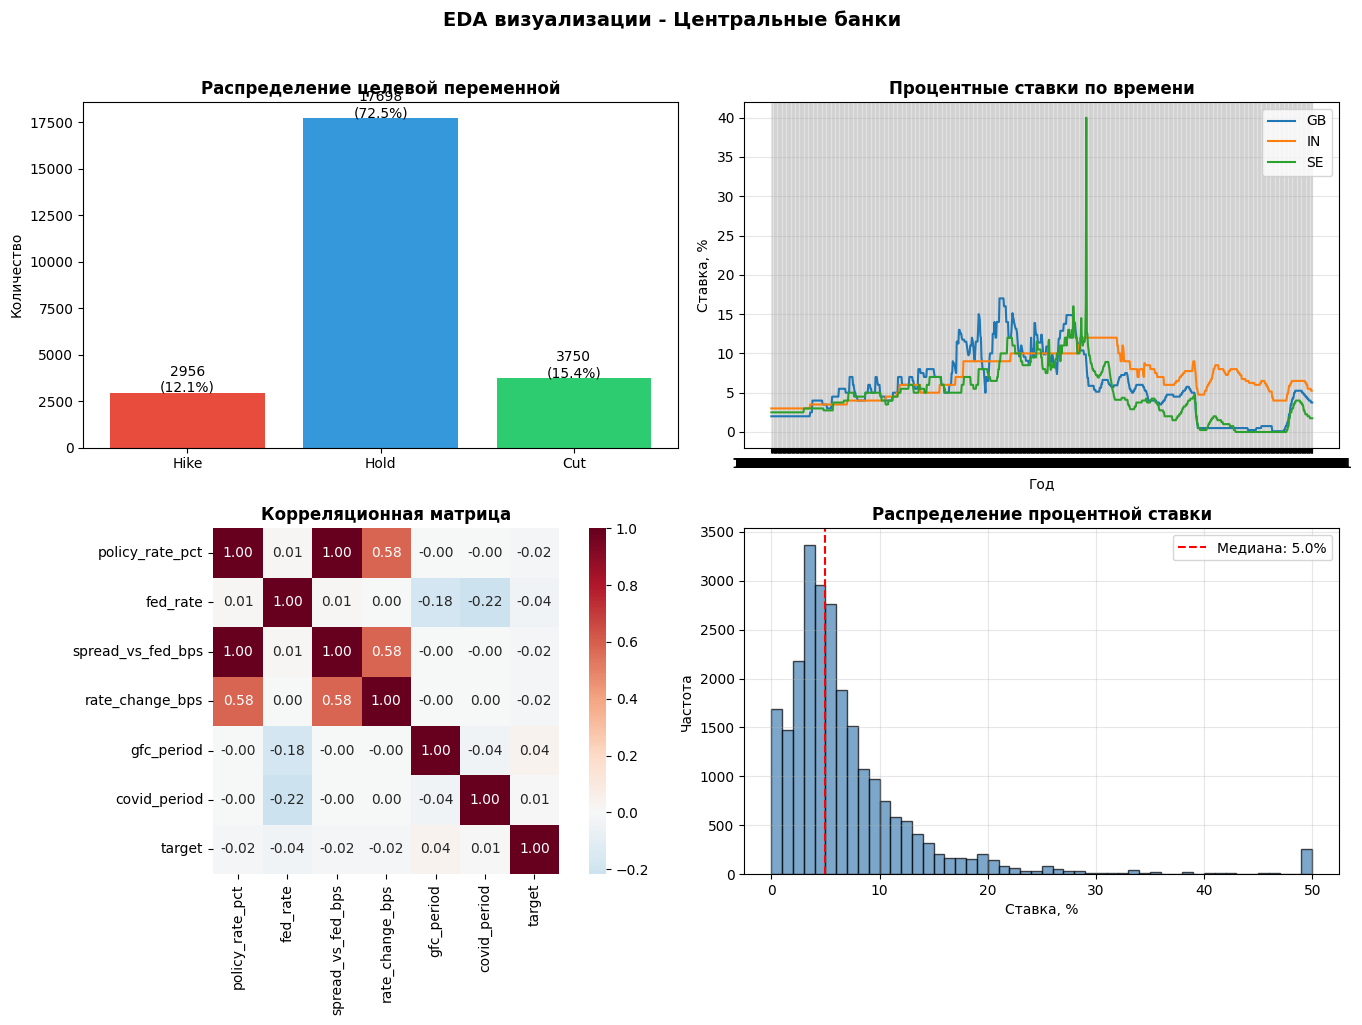

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()  

# 1. Распределение таргета
target_counts = df['target'].value_counts().sort_index()
total = len(df)

labels = ['Hike', 'Hold', 'Cut']
values = [target_counts.get(i, 0) for i in range(3)]
colors = ['#e74c3c', '#3498db', '#2ecc71']

bars = axes_flat[0].bar(labels, values, color=colors)
axes_flat[0].set_title('Распределение целевой переменной', fontsize=12, fontweight='bold')
axes_flat[0].set_ylabel('Количество')
for bar, count in zip(bars, values):
    axes_flat[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                   f'{count}\n({count/total*100:.1f}%)', ha='center', fontsize=10)

# 2. Ставка по времени для ТОП-3 стран
top_countries = df['country_code'].value_counts().head(3).index
for country in top_countries:
    country_data = df[df['country_code'] == country].sort_values('date')
    if len(country_data) > 0:
        axes_flat[1].plot(country_data['date'], country_data['policy_rate_pct'], 
                       label=country, linewidth=1.5)
axes_flat[1].set_title('Процентные ставки по времени', fontsize=12, fontweight='bold')
axes_flat[1].set_ylabel('Ставка, %')
axes_flat[1].set_xlabel('Год')
axes_flat[1].legend(loc='upper right')
axes_flat[1].grid(True, alpha=0.3)

# 3. Корреляция
numeric_cols = ['policy_rate_pct', 'fed_rate', 'spread_vs_fed_bps', 
                'rate_change_bps', 'gfc_period', 'covid_period', 'target']
available_cols = [col for col in numeric_cols if col in df.columns]
corr_df = df[available_cols].corr()
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            ax=axes_flat[2], square=True)
axes_flat[2].set_title('Корреляционная матрица', fontsize=12, fontweight='bold')

# 4. Распределение ставки
axes_flat[3].hist(df['policy_rate_pct'].clip(upper=50), bins=50, edgecolor='black', 
               color='steelblue', alpha=0.7)
axes_flat[3].set_title('Распределение процентной ставки', fontsize=12, fontweight='bold')
axes_flat[3].set_xlabel('Ставка, %')
axes_flat[3].set_ylabel('Частота')
axes_flat[3].axvline(df['policy_rate_pct'].median(), color='red', linestyle='--', 
                   label=f'Медиана: {df["policy_rate_pct"].median():.1f}%')
axes_flat[3].legend()
axes_flat[3].grid(True, alpha=0.3)

plt.suptitle('EDA визуализации - Центральные банки', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()


## Корректный сплит (train/val/test) и предотвращение data leak

**Почему используем временной сплит:**
- Данные представляют временной ряд (исторические данные ставок центральных банков)
- Использование случайного сплита привело бы к утечке будущих данных в обучающую выборку
- Модель должна учиться на прошлых данных и предсказывать будущие

**Разбиение:** 70% train / 15% validation / 15% test (по времени)

In [36]:
# Сортируем по дате для временного сплита
df = df.sort_values('date').reset_index(drop=True)

# Временной сплит (70/15/15)
train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))

train = df[:train_size]
val = df[train_size:train_size+val_size]
test = df[train_size+val_size:]

print("=== ВРЕМЕННОЙ СПЛИТ (избегаем data leak) ===")
print(f"Train: {len(train)} ({len(train)/len(df)*100:.1f}%) | {train['date'].min()} - {train['date'].max()}")
print(f"Val:   {len(val)} ({len(val)/len(df)*100:.1f}%) | {val['date'].min()} - {val['date'].max()}")
print(f"Test:  {len(test)} ({len(test)/len(df)*100:.1f}%) | {test['date'].min()} - {test['date'].max()}")

print(f"\nРаспределение классов в train: {train['target'].value_counts().sort_index().values}")
print(f"Распределение классов в val:   {val['target'].value_counts().sort_index().values}")
print(f"Распределение классов в test:  {test['target'].value_counts().sort_index().values}")

=== ВРЕМЕННОЙ СПЛИТ (избегаем data leak) ===
Train: 17082 (70.0%) | 1945-02-01 - 2009-11-01
Val:   3660 (15.0%) | 2009-11-01 - 2017-11-01
Test:  3662 (15.0%) | 2017-11-01 - 2026-02-01

Распределение классов в train: [ 2164 12074  2844]
Распределение классов в val:   [ 295 2933  432]
Распределение классов в test:  [ 497 2691  474]


Признаки и масштабирование

In [37]:
# Выбираем признаки
feature_cols = ['policy_rate_pct', 'fed_rate', 'spread_vs_fed_bps', 
                'rate_3m_avg', 'rate_12m_avg', 'rate_change_bps',
                'is_all_time_high', 'is_all_time_low', 'gfc_period', 
                'covid_period', 'hike_cycle_2022_23', 'year', 'month']

# Берем только существующие колонки
feature_cols = [col for col in feature_cols if col in df.columns]

X_train = train[feature_cols]
X_val = val[feature_cols]
y_train = train['target']
y_val = val['target']

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Признаков: {len(feature_cols)}")
print(f"Train shape: {X_train_scaled.shape}")

Признаков: 13
Train shape: (17082, 13)


## Выбор метрик качества и обоснование

**Почему F1-score (macro):**
- Данные несбалансированы (классы Hike/Hold/Cut имеют разное количество)
- Accuracy не подходит, так как не учитывает дисбаланс классов
- F1-score учитывает precision и recall для каждого класса
- Macro F1 вычисляет F1 для каждого класса и усредняет, давая равный вес всем классам
- Weighted F1 также выводим для сравнения (взвешивание по поддержке класса)

**Дополнительно выводим:**
- Classification report с precision, recall, support для каждого класса
- Confusion matrix для визуальной оценки ошибок классификации

=== МЕТРИКИ КАЧЕСТВА ===
Micro F1 (accuracy):  0.1227
Macro F1:             0.1377 ← основная метрика
Weighted F1:          0.0403

Classification Report:
              precision    recall  f1-score   support

        Hike       0.13      0.75      0.22       295
        Hold       0.00      0.00      0.00      2933
         Cut       0.11      0.53      0.19       432

    accuracy                           0.12      3660
   macro avg       0.08      0.43      0.14      3660
weighted avg       0.02      0.12      0.04      3660



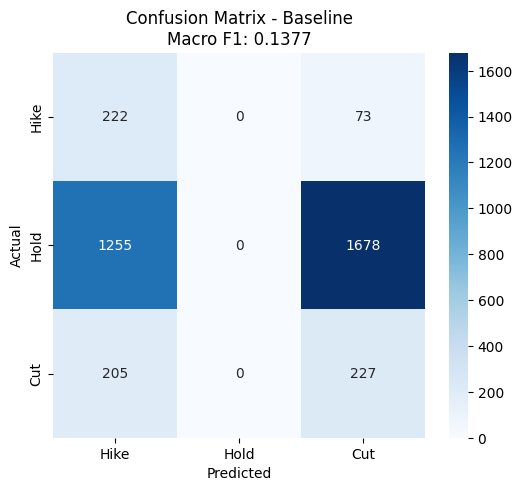

In [38]:


model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_val_scaled)
f1_macro = f1_score(y_val, y_pred, average='macro')
f1_weighted = f1_score(y_val, y_pred, average='weighted')
f1_micro = f1_score(y_val, y_pred, average='micro')

print(f"=== МЕТРИКИ КАЧЕСТВА ===")
print(f"Micro F1 (accuracy):  {f1_micro:.4f}")
print(f"Macro F1:             {f1_macro:.4f} ← основная метрика")
print(f"Weighted F1:          {f1_weighted:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Hike', 'Hold', 'Cut']))

# Матрица ошибок
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hike', 'Hold', 'Cut'],
            yticklabels=['Hike', 'Hold', 'Cut'])
plt.title(f'Confusion Matrix - Baseline\nMacro F1: {f1_macro:.4f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Итоги

In [40]:
print(f"Данные: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"Таргет: rate_change_direction (hike/hold/cut)")
print(f"Признаков в модели: {len(feature_cols)}")
print(f"Сплит: временной (train={len(train)}, val={len(val)}, test={len(test)})")
print(f"Метрика: Macro F1 = {f1_macro:.4f}")
print(f"Baseline: LogisticRegression")
print(f"Seed: {RANDOM_SEED}")

# Сохраняем результат
with open('../cp1_result.txt', 'w') as f:
    f.write(f"Macro F1: {f1_macro:.4f}\n")
    f.write(f"Weighted F1: {f1_weighted:.4f}\n")

Данные: 24404 строк, 46 колонок
Таргет: rate_change_direction (hike/hold/cut)
Признаков в модели: 13
Сплит: временной (train=17082, val=3660, test=3662)
Метрика: Macro F1 = 0.1377
Baseline: LogisticRegression
Seed: 42
